In [2]:
# pip install yfinance

In [4]:
# pip install nsepy

In [6]:
# pip install equitorium

In [1]:
from Descriptive import Descriptive

In [2]:
obj=Descriptive()

In [3]:
import yfinance as yf

stk_data = yf.download("ITC.NS",
                       start="2021-06-01",
                       end="2026-01-19")

# Remove MultiIndex if present
if isinstance(stk_data.columns, tuple) or hasattr(stk_data.columns, 'levels'):
    stk_data.columns = stk_data.columns.get_level_values(0)

stk_data = stk_data[['Open', 'High', 'Low', 'Close', 'Volume']]

print(stk_data.head())



[*********************100%***********************]  1 of 1 completed

Price             Open        High         Low       Close     Volume
Date                                                                 
2021-06-01  171.372432  172.472991  168.424513  169.210617   40247686
2021-06-02  165.476600  167.009519  163.982983  164.297424  100377464
2021-06-03  165.673115  165.673115  164.061579  164.336731   48454441
2021-06-04  164.690473  164.847693  163.511310  164.100891   31286264
2021-06-07  165.398000  166.970222  165.240779  166.223419   32643869


In [50]:
stk_data.to_csv("stk_data.csv")

In [4]:
stk_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1148 entries, 2021-06-01 to 2026-01-16
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1148 non-null   float64
 1   High    1148 non-null   float64
 2   Low     1148 non-null   float64
 3   Close   1148 non-null   float64
 4   Volume  1148 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.8 KB


In [5]:
low=stk_data["Low"]

In [6]:
dataset=stk_data
quan,qual=obj.segreQuanQual(dataset)

The Quantitative Data: ['Open', 'High', 'Low', 'Close', 'Volume']
The Qualtitative Data []


In [7]:
des_data=obj.descriptive_Analysis(dataset,quan)

In [8]:
des_data

,Open,High,Low,Close,Volume
Null_count,0,0,0,0,0
NonNull_count,1148,1148,1148,1148,1148
Total_Count,1148,1148,1148,1148,1148
Mean,334.120696,336.904585,331.06185,333.852693,16786735.099303
Median,384.083248,386.862217,381.131679,383.906876,12857205.0
Mode,163.264621,283.386785,394.137023,385.920624,0
Std,93.580382,94.088857,92.813481,93.365766,19037483.111999
Min,163.264621,163.547713,162.496212,162.657974,0.0
Q1:25%,254.326918,256.94655,253.372403,255.355675,9195721.0
Q2:50%,384.083248,386.862217,381.131679,383.906876,12857205.0


In [22]:
des_data["Low"]

Null_count                0
NonNull_count          1148
Total_Count            1148
Mean              331.06185
Median           381.131679
Mode             394.137023
Std               92.813481
Min              162.496212
Q1:25%           253.372403
Q2:50%           381.131679
Q3:75%           401.279115
Q4:100%          474.309509
IQR              147.906712
1.5Rule          221.860068
Lesser            31.512336
Greater          623.139182
Name: Low, dtype: object

In [23]:
des_data["High"]

Null_count                0
NonNull_count          1148
Total_Count            1148
Mean             336.904585
Median           386.862217
Mode             283.386785
Std               94.088857
Min              163.547713
Q1:25%            256.94655
Q2:50%           386.862217
Q3:75%           406.878141
Q4:100%          481.830977
IQR              149.931591
1.5Rule          224.897386
Lesser            32.049164
Greater          631.775527
Name: High, dtype: object

In [9]:
import numpy as np

In [10]:
np.percentile(dataset["Low"],99)

np.float64(463.44981828337353)

In [11]:
np.percentile(dataset["High"],80)

np.float64(412.65283463695283)

In [16]:
# pip install matplotlib

In [17]:
# pip install scipy

In [19]:
# pip install seaborn

In [20]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob

Mean=331.062, Standard Deviation=92.813
The area between range(420,475):0.10921121724555048


C:\Users\mojayara\AppData\Local\Temp\ipykernel_37864\132380739.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


np.float64(0.10921121724555048)

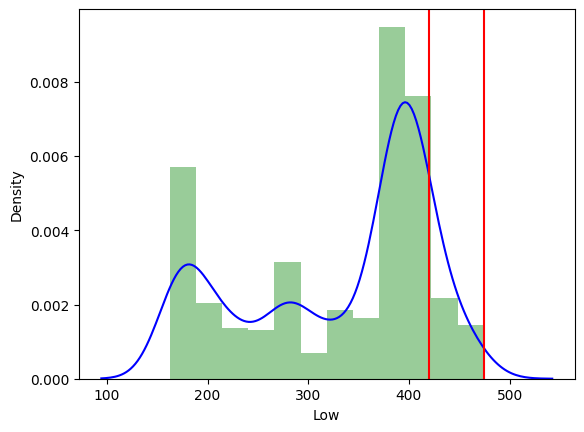

In [31]:
get_pdf_probability(dataset["Low"],420,475)

In [35]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.distplot(z_score,kde=True)

    sum(z_score)/len(z_score)
    #z_score.std()


In [36]:
# pip install seaborn

C:\Users\mojayara\AppData\Local\Temp\ipykernel_37864\2909774602.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


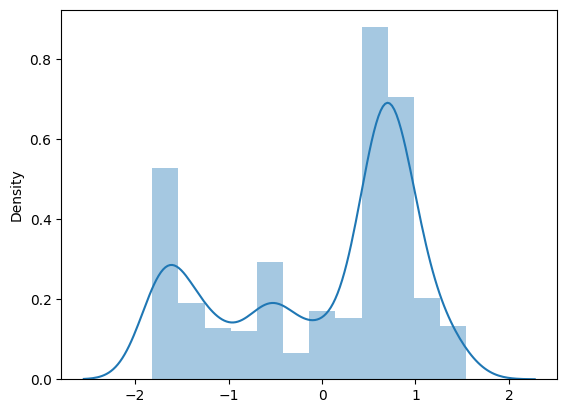

In [37]:
stdNBgraph(dataset["Low"])

In [38]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq

In [39]:
freqTable("Low",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,394.137023,2,0.174216,0.174216
1,168.424513,1,0.087108,0.261324
2,163.982983,1,0.087108,0.348432
3,164.061579,1,0.087108,0.435540
4,163.511310,1,0.087108,0.522648
...,...,...,...,...
1142,328.906887,1,0.087108,99.651568
1143,326.850026,1,0.087108,99.738676
1144,326.605146,1,0.087108,99.825784
1145,327.878448,1,0.087108,99.912892


In [40]:
freqTable("High",dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,284.235225,2,0.174216,0.174216
1,283.386785,2,0.174216,0.348432
2,172.472991,1,0.087108,0.435540
3,167.009519,1,0.087108,0.522648
4,165.673115,1,0.087108,0.609756
...,...,...,...,...
1141,332.530948,1,0.087108,99.651568
1142,332.530955,1,0.087108,99.738676
1143,329.102789,1,0.087108,99.825784
1144,327.878448,1,0.087108,99.912892


In [41]:
fh=freqTable("High",dataset)

In [42]:
fh.sort_values(by="Frequency",ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,284.235225,2,0.174216,0.174216
1,283.386785,2,0.174216,0.348432
2,172.472991,1,0.087108,0.435540
3,167.009519,1,0.087108,0.522648
4,165.673115,1,0.087108,0.609756
...,...,...,...,...
1141,332.530948,1,0.087108,99.651568
1142,332.530955,1,0.087108,99.738676
1143,329.102789,1,0.087108,99.825784
1144,327.878448,1,0.087108,99.912892


In [47]:
fhs=fh[fh["Frequency"]==2]["Unique_Values"].sort_values(ascending=False)

In [48]:
fhs

0    284.235225
1    283.386785
Name: Unique_Values, dtype: float64